In [ ]:
## Load packages and cleaned data
import pandas as pd
import matplotlib.pyplot as plt

import os
os.chdir('/Users/gracewang/Documents/Hertie/Data Structures & Algorithms/project-chaggg')

# ── Load cleaned data ─────────────────────────────────────────────────────────
df = pd.read_csv('data/cleaned/chicago_crimes_cleaned.csv', low_memory=False)

# district was saved as Int64 — restore it
df["district"] = pd.to_numeric(df["district"], errors="coerce").astype("Int64")

# Drop rows missing district or arrest
df = df.dropna(subset=["district", "arrest"])

In [ ]:
## Plot arrest rates by district into bar chart


# ── Calculate arrest rate per district ───────────────────────────────────────
summary = (
    df.groupby("district")
    .agg(
        total_crimes=("arrest", "count"),
        total_arrests=("arrest", "sum")
    )
    .assign(arrest_rate=lambda x: x["total_arrests"] / x["total_crimes"] * 100)
    .sort_values("district")
    .reset_index()
)

print(summary)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(
    summary["district"].astype(str),
    summary["arrest_rate"],
    color="steelblue",
    edgecolor="white",
    linewidth=0.5
)

# Annotate each bar with its rate
for bar, rate in zip(bars, summary["arrest_rate"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{rate:.1f}%",
        ha="center", va="bottom", fontsize=7
    )

ax.set_xlabel("Police District", fontsize=12)
ax.set_ylabel("Arrest Rate (%)", fontsize=12)
ax.set_title("Arrest Rate by Chicago Police District (2001–2025)", fontsize=14, fontweight="bold")
ax.set_ylim(0, summary["arrest_rate"].max() + 8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("arrest_rate_by_district.png", dpi=150)
plt.show()

In [ ]:
## Plot annual domestic violence incident count over time (2001–2025)

import pandas as pd
import matplotlib.pyplot as plt

# ── Load cleaned data ─────────────────────────────────────────────────────────
df = pd.read_csv('data/cleaned/chicago_crimes_cleaned.csv', low_memory=False)

# ── Filter for domestic violence crimes ──────────────────────────────────────
domestic = df[df["domestic"] == True]

# ── Group by year and count incidents ────────────────────────────────────────
yearly_counts = (
    domestic.groupby("year")
    .size()
    .reset_index(name="incident_count")
    .sort_values("year")
)

# Drop 2001 (high missing data) and 2025 (incomplete year)
yearly_counts = yearly_counts[yearly_counts["year"].between(2002, 2024)]

print(yearly_counts)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    yearly_counts["year"],
    yearly_counts["incident_count"],
    color="steelblue",
    linewidth=2,
    marker="o",
    markersize=5
)

# Annotate each point with its count
for _, row in yearly_counts.iterrows():
    ax.text(
        row["year"],
        row["incident_count"] + 500,
        f'{int(row["incident_count"]):,}',
        ha="center", va="bottom", fontsize=7
    )

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Number of Incidents", fontsize=12)
ax.set_title("Domestic Violence Incidents in Chicago by Year (2001–2025)", fontsize=14, fontweight="bold")
ax.set_xticks(yearly_counts["year"])
plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("domestic_violence_by_year.png", dpi=150)

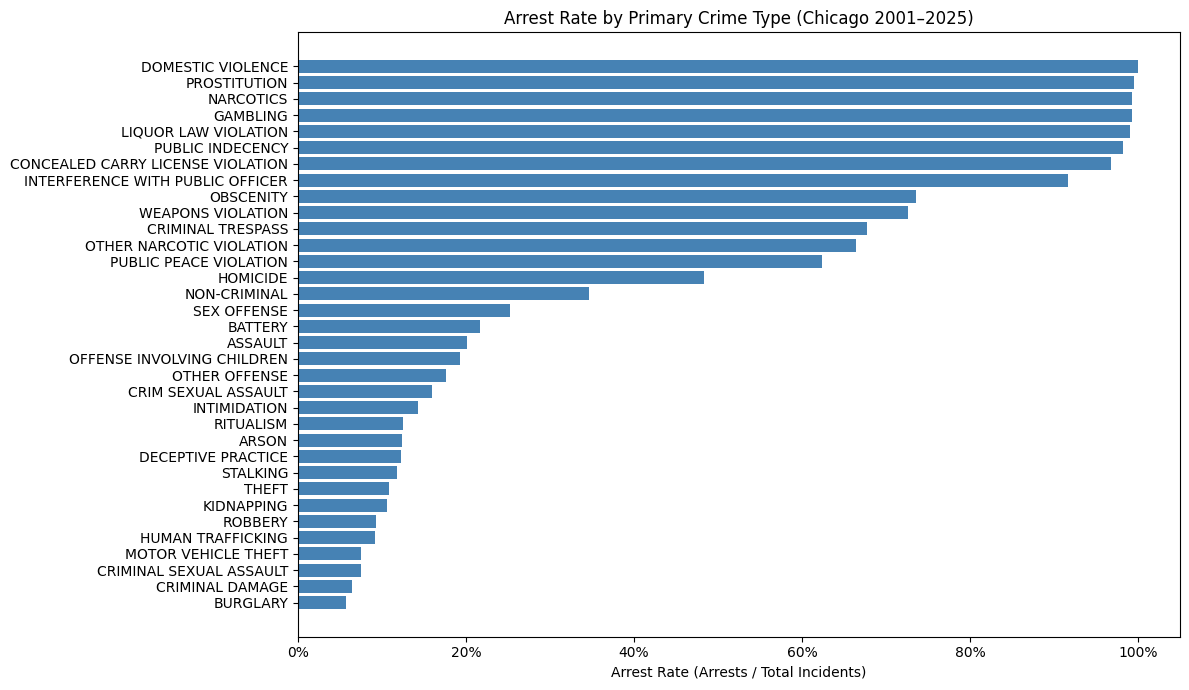

In [11]:
# Arrest rates by primary crime type
arrest_rates = (
    df.groupby("primary_type")
    .agg(total=("arrest", "count"), arrests=("arrest", "sum"))
    .assign(arrest_rate=lambda x: x["arrests"] / x["total"])
    .sort_values("arrest_rate", ascending=False)
    .reset_index()
)

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(arrest_rates["primary_type"], arrest_rates["arrest_rate"], color="steelblue")
ax.invert_yaxis()
ax.set_xlabel("Arrest Rate (Arrests / Total Incidents)")
ax.set_title("Arrest Rate by Primary Crime Type (Chicago 2001–2025)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.tight_layout()
plt.savefig("arrest_rate_by_primary_crime_type.png", dpi=150)
plt.show()

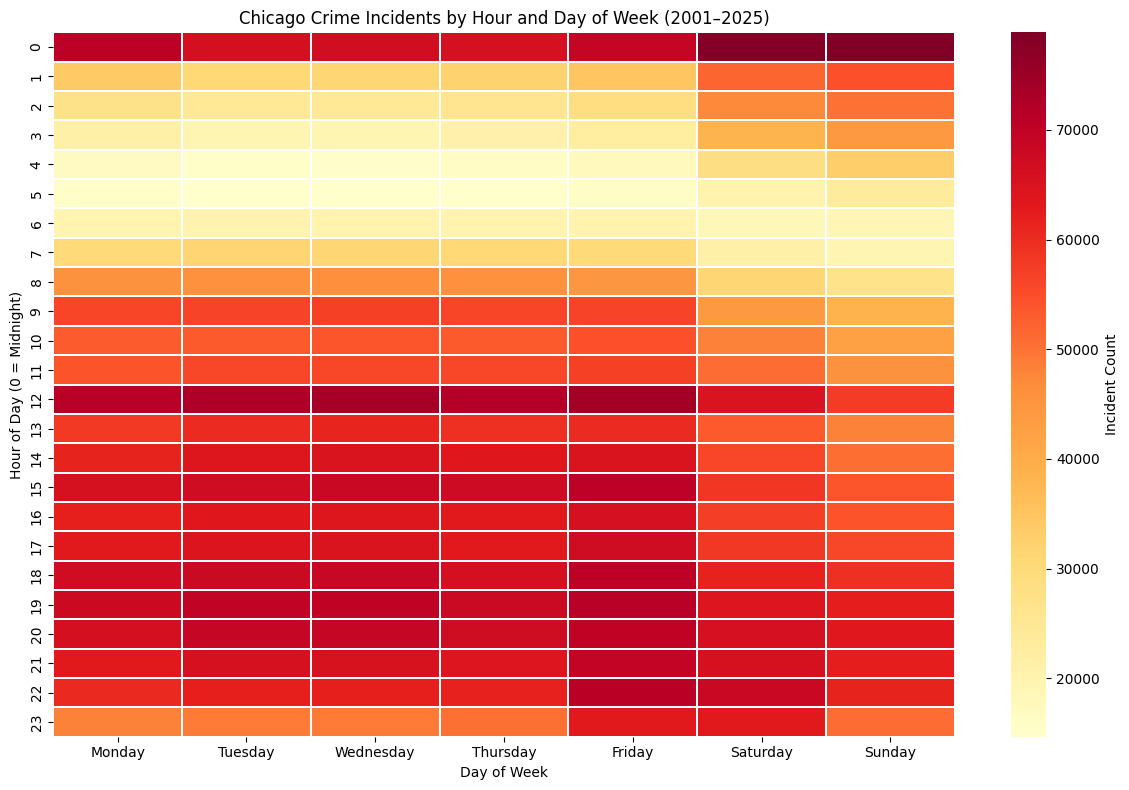

In [15]:
## Plot incident count by time of day (hour) and day of week (M, T, W, Th, etc.)
import seaborn as sns

# Parse date column if not already done
df["Date"] = pd.to_datetime(df["date"])
df["Time"] = pd.to_datetime(df["time"], format="%H:%M:%S")
df["Hour"] = df["Time"].dt.hour
df["DayOfWeek"] = df["Date"].dt.day_name()

# Pivot into hour x day matrix
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
heatmap_data = (
    df.groupby(["Hour", "DayOfWeek"])
    .size()
    .unstack("DayOfWeek")
    .reindex(columns=day_order)
)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    ax=ax,
    fmt=",",
    annot=False,
    linewidths=0.3,
    cbar_kws={"label": "Incident Count"}
)
ax.set_title("Chicago Crime Incidents by Hour and Day of Week (2001–2025)")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Hour of Day (0 = Midnight)")
plt.tight_layout()
plt.savefig("crimes_by_hour_and_day_of_week.png", dpi=150)
plt.show()